In [1]:
import argparse
import time
import warnings
import numpy as np
import torch

import utils
from data.preprocessing import toDataloader

warnings.filterwarnings("ignore")



parser = argparse.ArgumentParser()






parser = argparse.ArgumentParser()

parser.add_argument('--dataset', type=str, default='Training_Set_7P_PCA_SNmod_mock_train')


parser.add_argument('--multi_group', type=list, default=[1,2],
                    help='Input list')  # group<=math.ceil(sqrt(seq_len))
parser.add_argument('--batch', type=int, default=8, help='Dataset batch')
parser.add_argument('--lr', type=float, default=0.0001)
parser.add_argument('--nlayers', type=int, default=2)
parser.add_argument('--emb_size', type=int, default=128)
parser.add_argument('--nhead', type=int, default=8)
parser.add_argument('--emb_size_c', type=int, default=128)
parser.add_argument('--masking_ratio', type=float, default=0.01)
parser.add_argument('--epochs', type=int, default=30)
parser.add_argument('--ratio_highest_attention', type=float, default=0.35)
#parser.add_argument('--dropout', type=float, default=0.01)
parser.add_argument('--dropout', type=float, default=0.01)
parser.add_argument('--nhid', type=int, default=128)
parser.add_argument('--nhid_c', type=int, default=128)






args = parser.parse_args(args=[])
print(args)


def main():
    prop = utils.get_prop(args)
    prop['multi_group'] = [int(patch_index) for patch_index in prop['multi_group']]
    print('Data loading start...')
    X_train, y_train, X_test, y_test = utils.data_loader(args.dataset)

    prop['batch_true'] = X_train.shape[0]
    print('Data loading complete...')

    print('Data preprocessing start...')
    
    X_train_task, y_train_task, X_test, y_test,[mean_1,std_1] = utils.preprocess(X_train, y_train, X_test, y_test, prop)
    
   
    print('After standered:', X_train_task.shape, y_train_task.shape, X_test.shape, y_test.shape)
    print(X_train_task[0].shape)

    
    
    print('Data preprocessing complete...')

    
    prop['nclasses'] = torch.max(y_train_task).item() + 1
    prop['dataset'], prop['seq_len'], prop['input_size'] = prop['dataset'], X_train_task.shape[1], X_train_task.shape[2]
    prop['device'] = torch.device('cuda:0' if torch.cuda.is_available() else "cpu")

    
    dataloader_train, dataloader_test = toDataloader(prop, X_train_task, y_train_task, X_test, y_test)

    
    
    print('Initializing model...')
    t = time.time()
    
    model, criterion, optimizer = utils.initialize_training(prop)
    
    print('Model intialized...')

    print('Training start...')
    
    
    t = time.time() - t
    print(f"\nTraining time: {t / prop['epochs']}\n")

    print('Training complete...')


if __name__ == "__main__":
    main()


Namespace(dataset='Training_Set_7P_PCA_SNmod_mock_train', multi_group=[1, 2], batch=8, lr=0.0001, nlayers=2, emb_size=128, nhead=8, emb_size_c=128, masking_ratio=0.01, epochs=30, ratio_highest_attention=0.35, dropout=0.01, nhid=128, nhid_c=128)
Data loading start...
Data loading complete...
Data preprocessing start...
After standered: torch.Size([25449, 2, 106]) torch.Size([25449]) torch.Size([13562, 2, 106]) torch.Size([13562])
torch.Size([2, 106])
Data preprocessing complete...
Initializing model...
Model intialized...
Training start...

Training time: 0.046826473871866864

Training complete...


# 

Accuracy: 0.8143
F1 Score: 0.7985
Recall: 0.8143
Per-class metrics:
              precision    recall  f1-score   support

           0       0.88      0.99      0.93      1356
           1       0.81      0.80      0.81      1974
           2       0.55      0.30      0.39      1316
           3       0.60      0.51      0.55       611
           4       0.81      0.65      0.72      2487
           5       0.81      1.00      0.90      4631
           6       1.00      1.00      1.00      1187

    accuracy                           0.81     13562
   macro avg       0.78      0.75      0.76     13562
weighted avg       0.80      0.81      0.80     13562



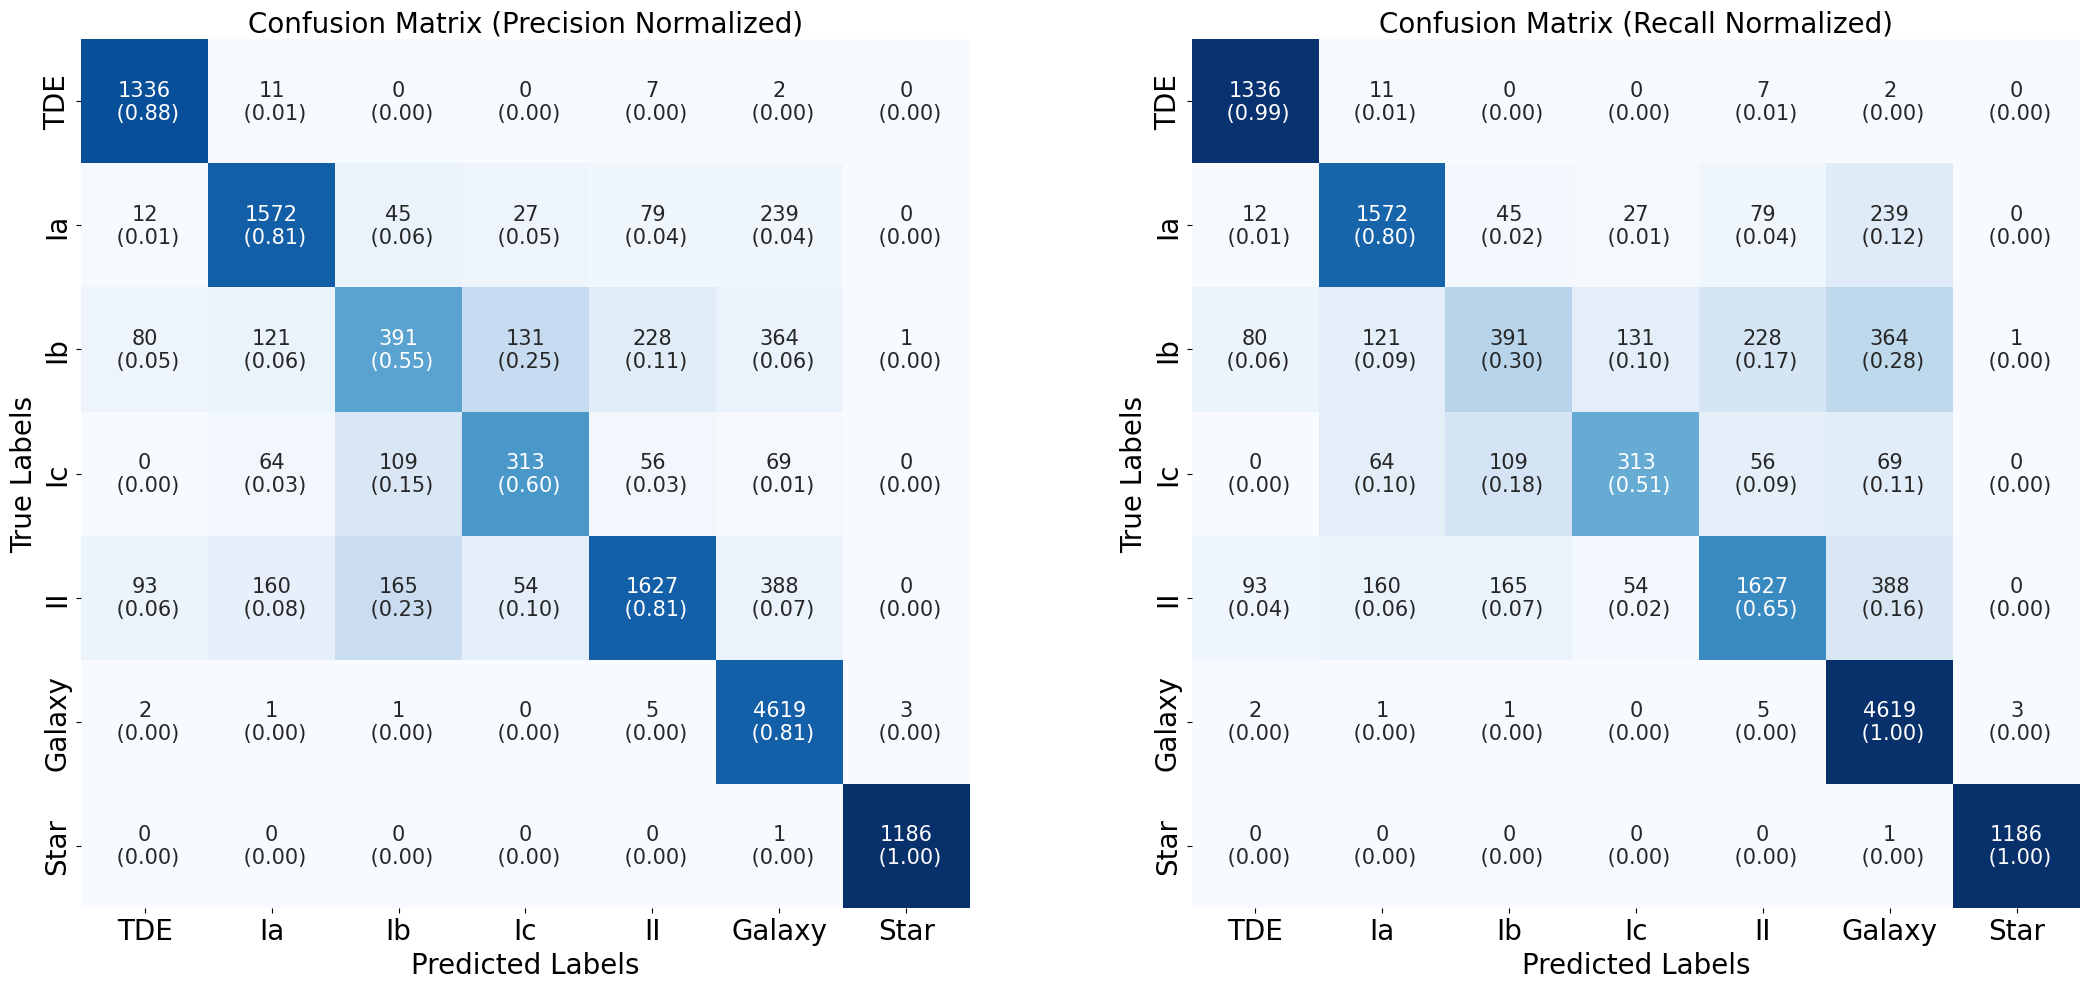

In [2]:
import math
import numpy as np
import random
import torch
import warnings
import utils

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report

from moudel.mgmcformer import MgMcFORMER

from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt



prop = utils.get_prop(args)

prop['multi_group'] = [int(patch_index) for patch_index in prop['multi_group']]
X_train, y_train, X_test, y_test = utils.data_loader(args.dataset)

#print(X_test)

prop['batch_true'] = X_train.shape[0]
X_train_task, y_train_task, X_test, y_test,[mean_1,std_1] = utils.preprocess(X_train, y_train, X_test, y_test, prop)


prop['nclasses'] = torch.max(y_train_task).item() + 1
prop['dataset'], prop['seq_len'], prop['input_size'] = prop['dataset'], X_train_task.shape[1], X_train_task.shape[2]
prop['device'] = torch.device('cuda:0' if torch.cuda.is_available() else "cpu")


model = MgMcFORMER(prop['multi_group'], prop['nclasses'], prop['seq_len'], prop['input_size'], prop['emb_size'], \
                       prop['nhid'], prop['emb_size_c'], prop['nhid_c'], prop['nhead'], prop['nlayers'], prop['device'],
                       prop['dropout']).to(prop['device'])


dataloader_train, dataloader_test = toDataloader(prop, X_train_task, y_train_task, X_test, y_test)

model.load_state_dict(torch.load("test_model_ZTF.pth"))






def test_model(model, dataloader_test, nclasses, device):
    model.eval()  # Turn on the evaluation mode

    output_arr = []
    label_arr = []
    with torch.no_grad():
        for data, label in dataloader_test:
            data = data.to(device)
            
            label = label.to(device)
            #print(data.shape)
            #print(model(data)[0].shape)
            pred = model(data)[0]
            
            output_arr.append(pred)
            label_arr.append(label)
            

    return label_arr,output_arr

nclasses=prop['nclasses']
label,output = test_model(model, dataloader_test, nclasses, device="cuda:0" )

#print(label)
#print(output)

# 将 labels 和 outputs 转换为 NumPy 数组
labels_np = torch.cat(label).cpu().numpy()
outputs_np = torch.argmax(torch.cat(output), dim=-1).cpu().numpy() 
logits = torch.cat(output)
probabilities = torch.softmax(logits, dim=-1)  # 转换为概率
#print(output)

#mask-filter
max_probs, predicted_classes = probabilities.max(dim=-1)
mask = max_probs > 0.01
#labels_np = labels_np[mask.cpu().numpy()]  # 只保留对应元素
#outputs_np = outputs_np[mask.cpu().numpy()]  # 同样筛选对应的预测


def prob_label_remix(probs,labels):
    for i in range(len(labels)):
        '''
        if probs[i][0] < 0.7 and probs[i][0] == np.max(np.array(probs[i].cpu())):
            # 获取两个最大值的下标
            top2_indices = probs[i].argsort()[-2:]
            # 最大的那个是最后一个，次大的那个是前一个
            second_max_index = top2_indices[0] if top2_indices[1] == 1 else top2_indices[1]
            labels[i] = second_max_index
        
        if probs[i][4]>=0.1:
            labels[i]=4
        '''
        if probs[i][0]>=0.05:
            labels[i]=0
        

        
        
        
        
       
       

    return labels
    pass


def wash_labels(labels,preds,probs):
    new_labels = [];new_preds = []
    for i in range(len(labels)):
        pro1 = np.array(probs[i].cpu())
        
        if np.max(np.array(probs[i].cpu()))>0.7:
            new_labels.append(labels[i])
            new_preds.append(preds[i])

    return new_labels,new_preds

labels_np = labels_np

#labels_np,outputs_np = wash_labels(labels_np,outputs_np,probabilities)
#outputs_np = prob_label_remix(probabilities,outputs_np)




'''
# 假设 labels_np 和 outputs_np 是已经准备好的 numpy 数组
# 计算精确度
accuracy = accuracy_score(labels_np, outputs_np)
print(f"Accuracy: {accuracy:.4f}")

# 计算 F1 分数
f1 = f1_score(labels_np, outputs_np, average='weighted')  # 可以选择 'micro', 'macro', 'weighted'
print(f"F1 Score: {f1:.4f}")

# 计算召回率
recall = recall_score(labels_np, outputs_np, average='weighted')
print(f"Recall: {recall:.4f}")

# 计算混淆矩阵
cm = confusion_matrix(labels_np, outputs_np)

# 归一化 - 精确度归一化 (按列归一化)
cm_precision = cm.astype('float') / cm.sum(axis=0, keepdims=True)

# 归一化 - 召回率归一化 (按行归一化)
cm_recall = cm.astype('float') / cm.sum(axis=1, keepdims=True)
label_map = {0: "TDE", 1: "SN Ia", 2: "SN II"} 
# 绘制精确度归一化后的混淆矩阵
plt.figure(figsize=(10, 16))

# 精确度归一化的热图
plt.subplot(2, 1, 1)
# 计算每个元素的文本，格式为 "(原始值, 归一化值)"
annot_text = [[f"{cm[i, j]}\n ({cm_precision[i, j]:.2f})" for j in range(cm.shape[1])] for i in range(cm.shape[0])]
sns.heatmap(cm_precision, annot=annot_text, fmt="", cmap="Blues", xticklabels=np.unique(labels_np), yticklabels=np.unique(labels_np))
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix (Precision Normalized)')

# 召回率归一化的热图
plt.subplot(2, 1, 2)
# 计算每个元素的文本，格式为 "(原始值, 归一化值)"
annot_text = [[f"{cm[i, j]}\n ({cm_recall[i, j]:.2f})" for j in range(cm.shape[1])] for i in range(cm.shape[0])]
sns.heatmap(cm_recall, annot=annot_text, fmt="", cmap="Blues", xticklabels=np.unique(labels_np), yticklabels=np.unique(labels_np))
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix (Recall Normalized)')

plt.tight_layout()
plt.show()
'''

# 数据准备

#directories = ['TDE',  'SN Ia',  'SN Ib', 'SN Ic',  'SN II', 'SN IIb',  'SN IIn', 'SN IIP',  ]
#directories = ['TDE',  'SN I',  'SN II'  ]
#directories = ['TDE',  'SN Ia','SN Ib/c', 'SN II','SLSN','AGN'  ]
#directories = ['TDE',  'Ia', 'Ia-91bg','Iax','Ibc','II', 'SLSN','KN','AGN' ]

#directories = ['TDE',  'SN Ia', 'SN II' ]
#directories = ['TDE',  'SN Ia', 'SN II' ]
#directories = ['TDE',  'SN Ia',  'SN IIb','SN IIn','SN IIP','AGN'  ]
#directories = ['TDE',  'Not-TDE'  ]
#labels = [0, 1, 2]
#labels = [0,1]
#labels = [0,1,2]
#directories = ['TDE','Not TDE']
#directories = ['TDE','SN Ia', 'SN II']

#directories = ['TDE','SN Ia', 'SN II','other SN']

#labels = [0, 1, 2]
directories = ['TDE',  'Ia','Ib','Ic','II','Galaxy','Star']
#directories = ['TDE',  'Ia','Ib','Ic','II','Galaxy-FL','Galaxy-SB','Galaxy-SF','AGN','AGN-BDL','Star']

#labels = [0, 1,2,3, 4,5,6 ]

#directories = ['TDE H','TDE He','TDE H+He',  'Ia-norm','Ia-91bg','Ia-91T','Ia-99a','Ia-02a','Ib','Ibn','Ic','II','IIb','IIn',
#               'Galaxy','AGN','Star']

labels = np.arange(0,7,1 )

# 构建映射关系
label_map = {labels[i]: directories[i] for i in range(len(labels))}

# 假设有真实标签和预测结果


# 计算性能指标
accuracy = accuracy_score(labels_np, outputs_np)
f1 = f1_score(labels_np, outputs_np, average='weighted')
recall = recall_score(labels_np, outputs_np, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Recall: {recall:.4f}")

print("Per-class metrics:")
print(classification_report(labels_np, outputs_np))


# 计算混淆矩阵
cm = confusion_matrix(labels_np, outputs_np)

# 归一化处理
cm_precision = cm.astype('float') / cm.sum(axis=0, keepdims=True)
cm_recall = cm.astype('float') / cm.sum(axis=1, keepdims=True)

# 绘制热图
plt.figure(figsize=(21, 10))

# 精确度归一化
plt.subplot(1, 2, 1)
annot_text = [[f"{cm[i, j]}\n ({cm_precision[i, j]:.2f})" if cm[j, :].sum() != 0 else f"{cm[i, j]}\n (N/A)" 
               for j in range(cm.shape[1])] for i in range(cm.shape[0])]
ax = sns.heatmap(cm_precision, annot=annot_text, fmt="", cmap="Blues", cbar=False,
            xticklabels=[label_map.get(i, i) for i in np.unique(labels_np)], 
            yticklabels=[label_map.get(i, i) for i in np.unique(labels_np)],
            annot_kws={"size": 15})
ax.tick_params(axis='x', labelsize=20)  # x轴标签字体大小
ax.tick_params(axis='y', labelsize=20)  # y轴标签字体大小
plt.xlabel('Predicted Labels',fontsize=20)
plt.ylabel('True Labels',fontsize=20)
plt.title('Confusion Matrix (Precision Normalized)',fontsize=20)

# 召回率归一化
plt.subplot(1, 2, 2)
annot_text = [[f"{cm[i, j]}\n ({cm_recall[i, j]:.2f})" if cm[i, :].sum() != 0 else f"{cm[i, j]}\n (N/A)" 
               for j in range(cm.shape[1])] for i in range(cm.shape[0])]
ax = sns.heatmap(cm_recall, annot=annot_text, fmt="", cmap="Blues", cbar=False,
            xticklabels=[label_map.get(i, i) for i in np.unique(labels_np)], 
            yticklabels=[label_map.get(i, i) for i in np.unique(labels_np)],
           annot_kws={"size": 15})
ax.tick_params(axis='x', labelsize=20)  # x轴标签字体大小
ax.tick_params(axis='y', labelsize=20)  # y轴标签字体大小

plt.xlabel('Predicted Labels',fontsize=20)
plt.ylabel('True Labels',fontsize=20)
#plt.title('Confusion Matrix (Recall Normalized) - score>0.05',fontsize=20)
plt.title('Confusion Matrix (Recall Normalized)',fontsize=20)

plt.tight_layout()
plt.subplots_adjust(wspace=0.25, hspace=0.4)
plt.savefig('model_another_s10.png')
plt.show()

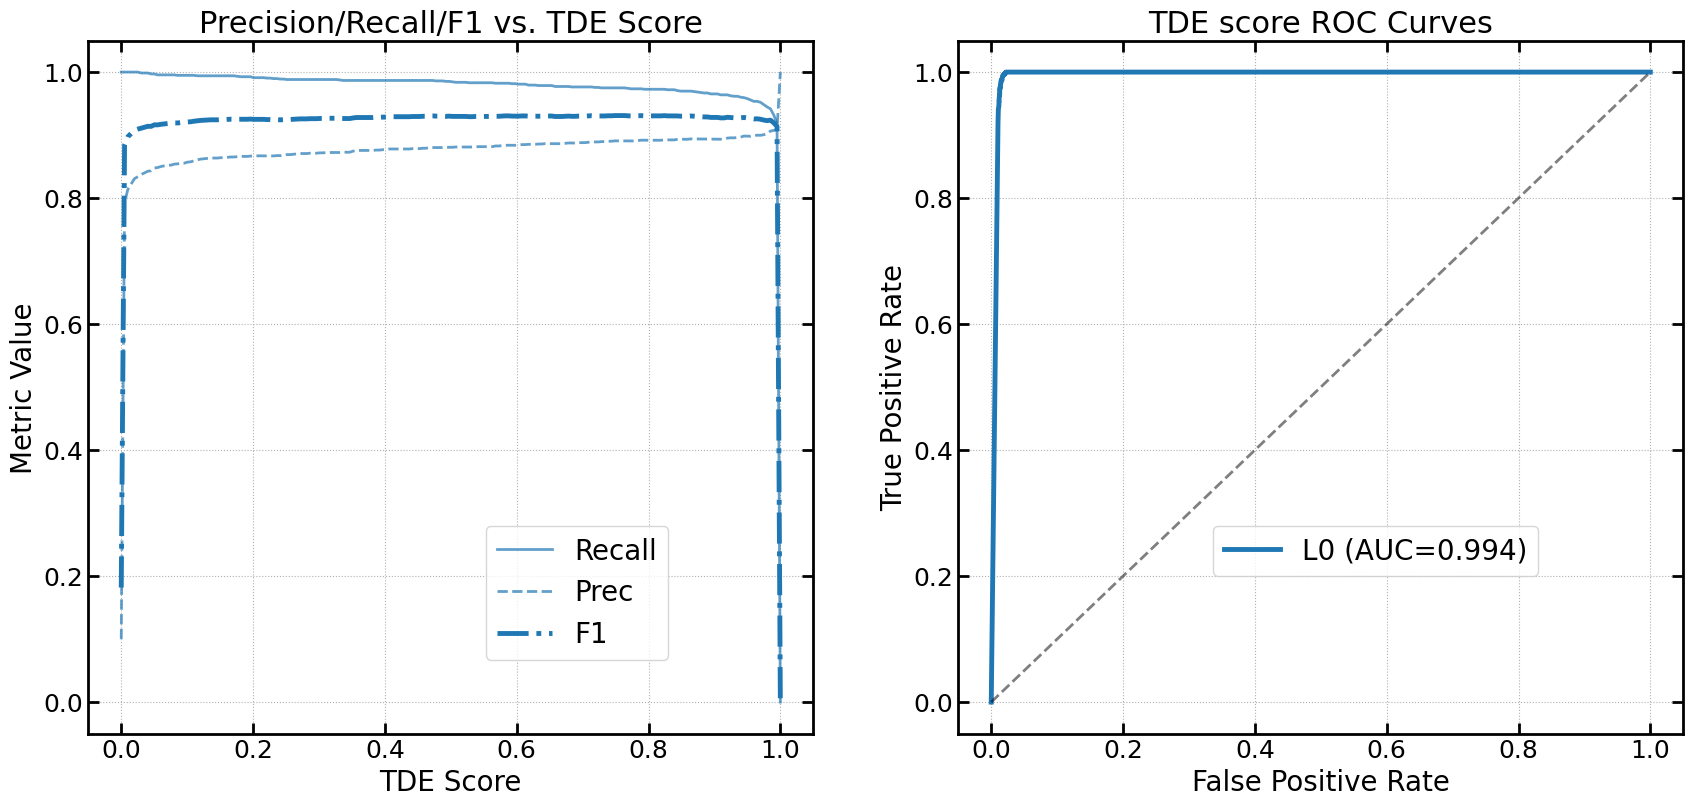

In [32]:
import numpy as np
import torch
from sklearn.metrics import confusion_matrix, auc
import matplotlib.pyplot as plt

def plot_multi_label_metrics_curves(
    label_list,
    output_list,
    target_labels,
    num_thresholds=200,
    plot=True,
    separate_plots=True
):
    # --- 1. 学术绘图风格设置 ---
    plt.rcParams.update({
        'font.size': 16,             
        'axes.linewidth': 2.0,       
        'xtick.direction': 'in',
        'ytick.direction': 'in',
        'xtick.top': True,
        'ytick.right': True,
        'axes.labelsize': 20,       
        'axes.titlesize': 22,        
        'legend.fontsize': 14,       
    })

    
    labels_np = torch.cat(label_list).cpu().numpy()
    logits = torch.cat(output_list)
    probabilities = torch.softmax(logits, dim=-1).cpu().numpy()

    thresholds = np.linspace(0.0, 1.0, num_thresholds)
    results = {}

    for target_label in target_labels:
        recalls, precisions, f1_scores, fprs = [], [], [], []
        binary_true = (labels_np == target_label).astype(int)

        for threshold in thresholds:
            binary_pred = (probabilities[:, target_label] >= threshold).astype(int)
            cm = confusion_matrix(binary_true, binary_pred, labels=[0, 1])
            tn, fp, fn, tp = cm.ravel()

            p = tp / (tp + fp) if (tp + fp) > 0 else 1.0
            r = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
            f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0

            precisions.append(p)
            recalls.append(r)
            fprs.append(fpr)
            f1_scores.append(f1)

        roc_auc = auc(fprs[::-1], recalls[::-1])
        results[target_label] = {
            'thresholds': thresholds, 'precisions': np.array(precisions),
            'recalls': np.array(recalls), 'f1_scores': np.array(f1_scores),
            'fprs': np.array(fprs), 'auc': roc_auc
        }

    if plot:
        if separate_plots:
            num_labels = len(target_labels)
            fig, axs = plt.subplots(num_labels, 2, figsize=(18, 8 * num_labels))
            if num_labels == 1: axs = np.expand_dims(axs, axis=0)

            for idx, target_label in enumerate(target_labels):
                res = results[target_label]
                ax0, ax1 = axs[idx, 0], axs[idx, 1]
                
                
                ax0.tick_params(axis='both', which='major', labelsize=16)
                ax1.tick_params(axis='both', which='major', labelsize=16)

                ax0.plot(res['thresholds'], res['recalls'], label='Recall', color='#1f77b4', lw=3)
                ax0.plot(res['thresholds'], res['precisions'], label='Precision', color='#2ca02c', ls='--', lw=3)
                ax0.plot(res['thresholds'], res['f1_scores'], label='F1-score', color='#d62728', ls='-.', lw=3)
                ax0.set_title(f"Label {target_label}: Metrics vs. Score")
                ax0.set_xlabel("TDE Score"); ax0.set_ylabel("Metric Value")
                #ax0.legend(loc="lower left", frameon=True)
                ax0.grid(True, ls=':', alpha=0.6)

                ax1.plot(res['fprs'], res['recalls'], color='#ff7f0e', lw=4, label=f'AUC = {res["auc"]:.4f}')
                ax1.plot([0, 1], [0, 1], color='#7f7f7f', ls='--', lw=2)
                ax1.set_title(f"ROC Curve")
                ax1.set_xlabel("False Positive Rate"); ax1.set_ylabel("True Positive Rate")
                #ax1.legend(loc="lower right")
                ax1.grid(True, ls=':', alpha=0.6)
        
        else:
            
            fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(22, 9))
            colors = plt.cm.get_cmap('tab10', len(target_labels))
            
            for i, target_label in enumerate(target_labels):
                res = results[target_label]
                c = colors(i)
                ax0.plot(res['thresholds'], res['recalls'], color=c, lw=2, alpha=0.7, label=f'Recall')
                ax0.plot(res['thresholds'], res['precisions'], color=c, ls='--', lw=2, alpha=0.7, label=f'Prec')
                ax0.plot(res['thresholds'], res['f1_scores'], color=c, ls='-.', lw=3.5, label=f'F1')
                ax1.plot(res['fprs'], res['recalls'], color=c, lw=3.5, label=f'L{target_label} (AUC={res["auc"]:.3f})')

            
            for ax in [ax0, ax1]:
                ax.tick_params(axis='both', which='major', labelsize=18, width=2, length=8)

            ax0.set_title("Precision/Recall/F1 vs. TDE Score")
            ax0.set_xlabel("TDE Score"); ax0.set_ylabel("Metric Value")
            
            ax0.legend( bbox_to_anchor=(0.8, 0.3), borderaxespad=0.,fontsize=20)
            ax0.grid(True, ls=':')
            
            ax1.set_title("TDE score ROC Curves")
            ax1.set_xlabel("False Positive Rate"); ax1.set_ylabel("True Positive Rate")
            ax1.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.5)
            ax1.legend( bbox_to_anchor=(0.8, 0.3), borderaxespad=0.,fontsize=20)
            ax1.grid(True, ls=':')

        
        plt.subplots_adjust(right=0.85) # 为右侧图例留出 15% 的宽度
        
        plt.savefig('prf1_ROC.pdf', bbox_inches='tight')
        plt.show()

    return results


res = plot_multi_label_metrics_curves(label, output, target_labels=[0], separate_plots=False)

Accuracy: 0.9847
F1 Score: 0.9851
Recall: 0.9847


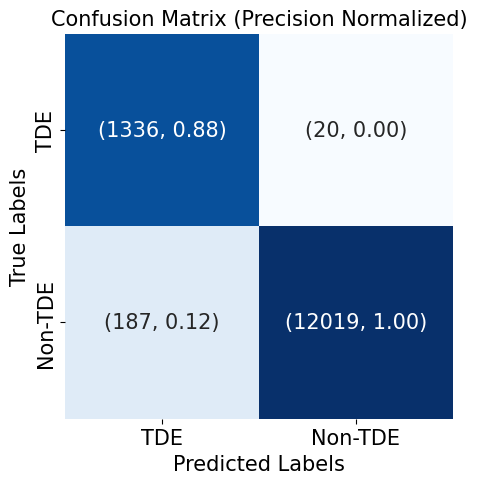

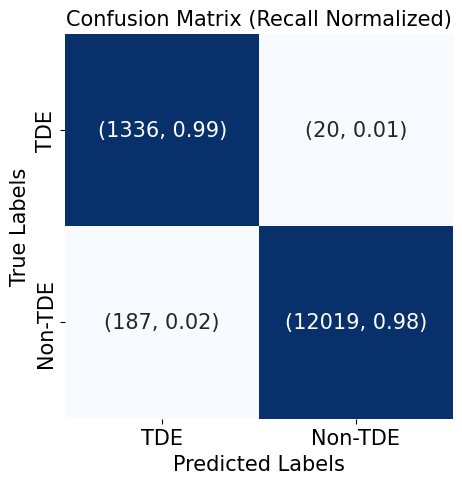

In [3]:
## import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix




labels_np_merged = labels_np
outputs_np_merged = outputs_np

labels_display = ['TDE', 'Not TDE']

# acc
accuracy = accuracy_score(labels_np_merged, outputs_np_merged)
print(f"Accuracy: {accuracy:.4f}")

# f1
f1 = f1_score(labels_np_merged, outputs_np_merged, average='weighted')  # 可以选择 'micro', 'macro', 'weighted'
print(f"F1 Score: {f1:.4f}")

# recall
recall = recall_score(labels_np_merged, outputs_np_merged, average='weighted')
print(f"Recall: {recall:.4f}")


cm = confusion_matrix(labels_np_merged, outputs_np_merged)


cm_precision = cm.astype('float') / cm.sum(axis=0, keepdims=True)

cm_recall = cm.astype('float') / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(5, 5))

labels_display = ['TDE', 'Non-TDE']


plt.subplot(1, 1, 1)
annot_text = [[f"({cm[i, j]}, {cm_precision[i, j]:.2f})" for j in range(cm.shape[1])] for i in range(cm.shape[0])]
sns.heatmap(cm_precision, annot=annot_text, fmt="", cmap="Blues",
            xticklabels=labels_display, yticklabels=labels_display, cbar=False,annot_kws={"size": 15})
plt.xlabel('Predicted Labels',fontsize=15)
plt.ylabel('True Labels',fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.title('Confusion Matrix (Precision Normalized)',fontsize=15)
plt.savefig('model_another_s11-3-pre.png',bbox_inches='tight', dpi=300)
plt.show()


# 召回率归一化的热图
plt.figure(figsize=(5, 5))
plt.subplot(1, 1, 1)
annot_text = [[f"({cm[i, j]}, {cm_recall[i, j]:.2f})" for j in range(cm.shape[1])] for i in range(cm.shape[0])]
sns.heatmap(cm_recall, annot=annot_text, fmt="", cmap="Blues",
            xticklabels=labels_display, yticklabels=labels_display, cbar=False,annot_kws={"size": 15} )
plt.xlabel('Predicted Labels',fontsize=15)
plt.ylabel('True Labels',fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.title('Confusion Matrix (Recall Normalized)',fontsize=15)

#plt.tight_layout()
plt.savefig('model_another_s11-3-rec.png',bbox_inches='tight', dpi=300)
plt.show()
